# AquaPlant — Phase G: Selective Prediction / Risk–Coverage Analysis

This notebook evaluates whether the calibrated models can become safer by **abstaining on uncertain predictions**.

### Models
- ResNet50 Fine-tuned
- EfficientNet-B0 Fine-tuned

### Input
Attach the saved Phase-F artifact package:

`AquaPlant_PhaseF_Calibration_Uncertainty_Artifacts.zip`

The notebook reuses the calibrated locked-Test probabilities saved in Phase F. It does **not** retrain the networks or run model inference again.

### Main outputs
- Coverage
- Selective Accuracy
- Selective Risk
- AURC and E-AURC
- Error Rejection Rate
- Fixed-coverage analysis
- Pre-specified confidence-threshold analysis
- Risk–coverage and selective-accuracy figures
- High-confidence error list for later Grad-CAM/error analysis
- Final Phase-G artifact ZIP

**Important:** Confidence thresholds are reported descriptively on Test. Do not choose a deployment threshold by optimizing these Test results.

In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT
# ============================================================

import os
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
EXPECTED_TEST_IMAGES = 157
EXPECTED_CLASSES = 14

MODEL_NAMES = [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned",
]

CONFIDENCE_THRESHOLDS = [
    0.50, 0.60, 0.70, 0.80,
    0.85, 0.90, 0.95, 0.97, 0.99
]

TARGET_COVERAGES = [
    1.00, 0.95, 0.90, 0.80,
    0.70, 0.60, 0.50
]

print("=" * 78)
print("PHASE G — SELECTIVE PREDICTION / RISK-COVERAGE")
print("=" * 78)

print("\nKaggle inputs:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

print("\n✅ Phase G environment ready")
print("✅ Phase-F calibrated probabilities will be reused")
print("🔒 No training or model tuning will be performed")
print("🔒 Test will not be used to optimize a deployment threshold")


PHASE G — SELECTIVE PREDICTION / RISK-COVERAGE

Kaggle inputs:
 - datasets

✅ Phase G environment ready
✅ Phase-F calibrated probabilities will be reused
🔒 No training or model tuning will be performed
🔒 Test will not be used to optimize a deployment threshold


In [2]:
# ============================================================
# CELL 2 — FIND / EXTRACT PHASE-F ARRAYS
# ============================================================

def collect_files(root):
    found = []
    for current_root, dirs, files in os.walk(root):
        for file in files:
            found.append(os.path.join(current_root, file))
    return found

ALL_FILES = collect_files("/kaggle/input")

def find_phasef_npz(model_name, files):
    target = f"phaseF_{model_name}_calibration_arrays.npz".lower()

    for path in files:
        if os.path.basename(path).lower() == target:
            return path

    return None

RESNET_NPZ = find_phasef_npz("ResNet50_Finetuned", ALL_FILES)
EFFNET_NPZ = find_phasef_npz("EfficientNetB0_Finetuned", ALL_FILES)

if RESNET_NPZ is None or EFFNET_NPZ is None:
    EXTRACT_ROOT = "/kaggle/working/phaseG_phaseF_extracted"
    os.makedirs(EXTRACT_ROOT, exist_ok=True)

    for zip_path in [
        p for p in ALL_FILES
        if p.lower().endswith(".zip")
    ]:
        try:
            with zipfile.ZipFile(zip_path, "r") as z:
                names = [n.lower() for n in z.namelist()]

                is_phasef = any(
                    "phasef_" in n and "calibration_arrays.npz" in n
                    for n in names
                )

                if not is_phasef:
                    continue

                target_dir = os.path.join(
                    EXTRACT_ROOT,
                    Path(zip_path).stem
                )

                os.makedirs(target_dir, exist_ok=True)
                z.extractall(target_dir)

        except Exception:
            pass

    ALL_FILES.extend(
        collect_files(EXTRACT_ROOT)
    )

    RESNET_NPZ = RESNET_NPZ or find_phasef_npz(
        "ResNet50_Finetuned",
        ALL_FILES
    )

    EFFNET_NPZ = EFFNET_NPZ or find_phasef_npz(
        "EfficientNetB0_Finetuned",
        ALL_FILES
    )

print("=" * 78)
print("PHASE-F ARRAY DETECTION")
print("=" * 78)

print("\nResNet50:")
print(RESNET_NPZ)

print("\nEfficientNet-B0:")
print(EFFNET_NPZ)

assert RESNET_NPZ is not None, "❌ ResNet50 Phase-F arrays not found."
assert EFFNET_NPZ is not None, "❌ EfficientNet-B0 Phase-F arrays not found."

print("\n✅ Both Phase-F calibrated archives found")


PHASE-F ARRAY DETECTION

ResNet50:
/kaggle/input/datasets/srabondcosta/phase-f-aquatic/phaseF_ResNet50_Finetuned_calibration_arrays.npz

EfficientNet-B0:
/kaggle/input/datasets/srabondcosta/phase-f-aquatic/phaseF_EfficientNetB0_Finetuned_calibration_arrays.npz

✅ Both Phase-F calibrated archives found


In [3]:
# ============================================================
# CELL 3 — LOAD + VERIFY CALIBRATED TEST ARRAYS
# ============================================================

def load_phasef_array(path):
    data = np.load(path, allow_pickle=True)

    required_keys = [
        "image_paths",
        "class_names",
        "y_true",
        "y_pred",
        "probabilities_after",
        "confidence_after",
        "entropy_after",
        "temperature",
    ]

    missing = [
        key for key in required_keys
        if key not in data.files
    ]

    assert not missing, f"❌ Missing keys: {missing}"

    return {
        key: data[key]
        for key in data.files
    }

phaseF_arrays = {
    "ResNet50_Finetuned": load_phasef_array(RESNET_NPZ),
    "EfficientNetB0_Finetuned": load_phasef_array(EFFNET_NPZ),
}

reference_classes = None
reference_labels = None

for model_name, data in phaseF_arrays.items():
    probs = np.asarray(
        data["probabilities_after"],
        dtype=np.float64
    )

    y_true = np.asarray(
        data["y_true"],
        dtype=np.int64
    )

    y_pred = np.asarray(
        data["y_pred"],
        dtype=np.int64
    )

    confidence = np.asarray(
        data["confidence_after"],
        dtype=np.float64
    )

    entropy = np.asarray(
        data["entropy_after"],
        dtype=np.float64
    )

    class_names = [
        str(x)
        for x in data["class_names"]
    ]

    image_paths = [
        str(x)
        for x in data["image_paths"]
    ]

    pred_from_probs = probs.argmax(axis=1)
    conf_from_probs = probs.max(axis=1)

    assert probs.shape == (
        EXPECTED_TEST_IMAGES,
        EXPECTED_CLASSES
    )

    assert y_true.shape == (
        EXPECTED_TEST_IMAGES,
    )

    assert np.allclose(
        probs.sum(axis=1),
        1.0,
        atol=1e-5
    )

    assert np.array_equal(
        pred_from_probs,
        y_pred
    )

    assert np.allclose(
        conf_from_probs,
        confidence,
        atol=1e-6
    )

    assert len(class_names) == EXPECTED_CLASSES
    assert len(image_paths) == EXPECTED_TEST_IMAGES

    if reference_classes is None:
        reference_classes = class_names
        reference_labels = y_true.copy()
    else:
        assert class_names == reference_classes
        assert np.array_equal(
            y_true,
            reference_labels
        )

    data["probabilities_after"] = probs
    data["y_true"] = y_true
    data["y_pred"] = y_pred
    data["confidence_after"] = confidence
    data["entropy_after"] = entropy
    data["class_names"] = class_names
    data["image_paths"] = image_paths

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    temperature = float(
        np.asarray(
            data["temperature"]
        ).reshape(-1)[0]
    )

    print("\n" + "=" * 78)
    print(model_name)
    print("=" * 78)
    print("Test images     :", len(y_true))
    print("Classes         :", len(class_names))
    print(f"Accuracy        : {accuracy * 100:.2f}%")
    print(f"Macro-F1        : {macro_f1 * 100:.2f}%")
    print(f"Mean confidence : {confidence.mean() * 100:.2f}%")
    print(f"Temperature     : {temperature:.6f}")

print("\n✅ Calibrated Test outputs verified")
print("✅ Both models use identical Test labels and class order")



ResNet50_Finetuned
Test images     : 157
Classes         : 14
Accuracy        : 96.18%
Macro-F1        : 95.90%
Mean confidence : 96.13%
Temperature     : 0.445357

EfficientNetB0_Finetuned
Test images     : 157
Classes         : 14
Accuracy        : 95.54%
Macro-F1        : 95.21%
Mean confidence : 96.48%
Temperature     : 0.587467

✅ Calibrated Test outputs verified
✅ Both models use identical Test labels and class order


In [4]:
# ============================================================
# CELL 4 — SELECTIVE-PREDICTION FUNCTIONS
# ============================================================

def risk_coverage_curve_from_order(y_true, y_pred, order):
    # order contains indices from most certain to least certain.
    correct = (
        y_pred[order] == y_true[order]
    ).astype(np.int64)

    errors = 1 - correct

    cumulative_errors = np.cumsum(errors)

    k = np.arange(
        1,
        len(y_true) + 1
    )

    coverage = k / len(y_true)
    risk = cumulative_errors / k
    selective_accuracy = 1.0 - risk

    return (
        coverage,
        risk,
        selective_accuracy
    )

def discrete_aurc(risk):
    # Discrete area under the risk-coverage curve.
    # Lower is better.
    return float(
        np.mean(risk)
    )

def optimal_aurc(y_true, y_pred):
    # Best possible ranking for the same fixed predictions:
    # all correct predictions first, then all errors.
    n = len(y_true)

    n_errors = int(
        np.sum(
            y_pred != y_true
        )
    )

    n_correct = n - n_errors

    optimal_error_sequence = np.concatenate([
        np.zeros(
            n_correct,
            dtype=np.int64
        ),
        np.ones(
            n_errors,
            dtype=np.int64
        ),
    ])

    cumulative_errors = np.cumsum(
        optimal_error_sequence
    )

    k = np.arange(
        1,
        n + 1
    )

    optimal_risk = (
        cumulative_errors / k
    )

    return float(
        np.mean(
            optimal_risk
        )
    )

def curve_from_confidence(
    y_true,
    y_pred,
    confidence
):
    order = np.argsort(
        -confidence,
        kind="mergesort"
    )

    return risk_coverage_curve_from_order(
        y_true,
        y_pred,
        order
    )

def curve_from_entropy(
    y_true,
    y_pred,
    entropy
):
    order = np.argsort(
        entropy,
        kind="mergesort"
    )

    return risk_coverage_curve_from_order(
        y_true,
        y_pred,
        order
    )

print("✅ Selective-prediction functions ready")


✅ Selective-prediction functions ready


In [5]:
# ============================================================
# CELL 5 — AURC / E-AURC ANALYSIS
# ============================================================

risk_coverage_results = {}
aurc_rows = []

for model_name, data in phaseF_arrays.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    confidence = data["confidence_after"]
    entropy = data["entropy_after"]

    (
        coverage_conf,
        risk_conf,
        selective_acc_conf
    ) = curve_from_confidence(
        y_true,
        y_pred,
        confidence
    )

    (
        coverage_ent,
        risk_ent,
        selective_acc_ent
    ) = curve_from_entropy(
        y_true,
        y_pred,
        entropy
    )

    aurc_conf = discrete_aurc(
        risk_conf
    )

    aurc_ent = discrete_aurc(
        risk_ent
    )

    aurc_opt = optimal_aurc(
        y_true,
        y_pred
    )

    risk_coverage_results[model_name] = {
        "coverage_confidence": coverage_conf,
        "risk_confidence": risk_conf,
        "selective_accuracy_confidence": selective_acc_conf,
        "coverage_entropy": coverage_ent,
        "risk_entropy": risk_ent,
        "selective_accuracy_entropy": selective_acc_ent,
    }

    aurc_rows.extend([
        {
            "Model": model_name,
            "Uncertainty Score": "Calibrated confidence",
            "AURC": aurc_conf,
            "Optimal AURC": aurc_opt,
            "E-AURC": aurc_conf - aurc_opt,
        },
        {
            "Model": model_name,
            "Uncertainty Score": "Predictive entropy",
            "AURC": aurc_ent,
            "Optimal AURC": aurc_opt,
            "E-AURC": aurc_ent - aurc_opt,
        },
    ])

aurc_df = pd.DataFrame(
    aurc_rows
)

display(
    aurc_df.round(6)
)

AURC_PATH = (
    "/kaggle/working/"
    "phaseG_aurc_summary.csv"
)

aurc_df.to_csv(
    AURC_PATH,
    index=False
)

print("\n✅ Saved:", AURC_PATH)
print("ℹ️ Lower AURC / E-AURC = better uncertainty ranking")


,Model,Uncertainty Score,AURC,Optimal AURC,E-AURC
0,ResNet50_Finetuned,Calibrated confidence,0.003375,0.000861,0.002514
1,ResNet50_Finetuned,Predictive entropy,0.003035,0.000861,0.002174
2,EfficientNetB0_Finetuned,Calibrated confidence,0.005918,0.001151,0.004767
3,EfficientNetB0_Finetuned,Predictive entropy,0.005963,0.001151,0.004812



✅ Saved: /kaggle/working/phaseG_aurc_summary.csv
ℹ️ Lower AURC / E-AURC = better uncertainty ranking


In [6]:
# ============================================================
# CELL 6 — FIXED-COVERAGE ANALYSIS
# ============================================================

fixed_coverage_rows = []

for model_name, data in phaseF_arrays.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    confidence = data["confidence_after"]

    order = np.argsort(
        -confidence,
        kind="mergesort"
    )

    n = len(y_true)

    total_errors = int(
        np.sum(
            y_pred != y_true
        )
    )

    for target_coverage in TARGET_COVERAGES:
        k = max(
            1,
            int(
                np.ceil(
                    target_coverage * n
                )
            )
        )

        selected_indices = order[:k]

        selected_true = y_true[
            selected_indices
        ]

        selected_pred = y_pred[
            selected_indices
        ]

        selected_conf = confidence[
            selected_indices
        ]

        accepted_errors = int(
            np.sum(
                selected_pred != selected_true
            )
        )

        selective_accuracy = accuracy_score(
            selected_true,
            selected_pred
        )

        selective_risk = (
            1.0 - selective_accuracy
        )

        actual_coverage = (
            k / n
        )

        rejected_images = (
            n - k
        )

        rejected_errors = (
            total_errors
            - accepted_errors
        )

        error_rejection_rate = (
            rejected_errors / total_errors
            if total_errors > 0
            else np.nan
        )

        fixed_coverage_rows.append({
            "Model": model_name,
            "Target Coverage": target_coverage,
            "Actual Coverage": actual_coverage,
            "Accepted Images": k,
            "Rejected Images": rejected_images,
            "Selective Accuracy": selective_accuracy,
            "Selective Risk": selective_risk,
            "Mean Accepted Confidence": float(
                selected_conf.mean()
            ),
            "Accepted Errors": accepted_errors,
            "Rejected Errors": rejected_errors,
            "Error Rejection Rate": error_rejection_rate,
        })

fixed_coverage_df = pd.DataFrame(
    fixed_coverage_rows
)

display(
    fixed_coverage_df.round(6)
)

FIXED_COVERAGE_PATH = (
    "/kaggle/working/"
    "phaseG_fixed_coverage_results.csv"
)

fixed_coverage_df.to_csv(
    FIXED_COVERAGE_PATH,
    index=False
)

print("\n✅ Saved:", FIXED_COVERAGE_PATH)


,Model,Target Coverage,Actual Coverage,Accepted Images,Rejected Images,Selective Accuracy,Selective Risk,Mean Accepted Confidence,Accepted Errors,Rejected Errors,Error Rejection Rate
0,ResNet50_Finetuned,1.00,1.000000,157,0,0.961783,0.038217,0.961250,6,0,0.000000
1,ResNet50_Finetuned,0.95,0.955414,150,7,0.973333,0.026667,0.982042,4,2,0.333333
2,ResNet50_Finetuned,0.90,0.904459,142,15,0.992958,0.007042,0.993000,1,5,0.833333
3,ResNet50_Finetuned,0.80,0.802548,126,31,0.992063,0.007937,0.998421,1,5,0.833333
4,ResNet50_Finetuned,0.70,0.700637,110,47,1.000000,0.000000,0.999512,0,6,1.000000
5,ResNet50_Finetuned,0.60,0.605096,95,62,1.000000,0.000000,0.999819,0,6,1.000000
6,ResNet50_Finetuned,0.50,0.503185,79,78,1.000000,0.000000,0.999933,0,6,1.000000
7,EfficientNetB0_Finetuned,1.00,1.000000,157,0,0.955414,0.044586,0.964755,7,0,0.000000
8,EfficientNetB0_Finetuned,0.95,0.955414,150,7,0.980000,0.020000,0.986641,3,4,0.571429
9,EfficientNetB0_Finetuned,0.90,0.904459,142,15,0.978873,0.021127,0.994745,3,4,0.571429



✅ Saved: /kaggle/working/phaseG_fixed_coverage_results.csv


In [7]:
# ============================================================
# CELL 7 — PRE-SPECIFIED CONFIDENCE-THRESHOLD SWEEP
# ============================================================

threshold_rows = []

for model_name, data in phaseF_arrays.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    confidence = data["confidence_after"]

    n = len(y_true)

    total_errors = int(
        np.sum(
            y_pred != y_true
        )
    )

    for threshold in CONFIDENCE_THRESHOLDS:
        accepted_mask = (
            confidence >= threshold
        )

        accepted_count = int(
            accepted_mask.sum()
        )

        rejected_count = (
            n - accepted_count
        )

        if accepted_count == 0:
            threshold_rows.append({
                "Model": model_name,
                "Confidence Threshold": threshold,
                "Coverage": 0.0,
                "Accepted Images": 0,
                "Rejected Images": n,
                "Selective Accuracy": np.nan,
                "Selective Risk": np.nan,
                "Mean Accepted Confidence": np.nan,
                "Accepted Errors": 0,
                "Rejected Errors": total_errors,
                "Error Rejection Rate":
                    1.0 if total_errors > 0 else np.nan,
            })
            continue

        selected_true = y_true[
            accepted_mask
        ]

        selected_pred = y_pred[
            accepted_mask
        ]

        selected_conf = confidence[
            accepted_mask
        ]

        accepted_errors = int(
            np.sum(
                selected_pred != selected_true
            )
        )

        rejected_errors = (
            total_errors
            - accepted_errors
        )

        selective_accuracy = accuracy_score(
            selected_true,
            selected_pred
        )

        selective_risk = (
            1.0 - selective_accuracy
        )

        error_rejection_rate = (
            rejected_errors / total_errors
            if total_errors > 0
            else np.nan
        )

        threshold_rows.append({
            "Model": model_name,
            "Confidence Threshold": threshold,
            "Coverage": accepted_count / n,
            "Accepted Images": accepted_count,
            "Rejected Images": rejected_count,
            "Selective Accuracy": selective_accuracy,
            "Selective Risk": selective_risk,
            "Mean Accepted Confidence": float(
                selected_conf.mean()
            ),
            "Accepted Errors": accepted_errors,
            "Rejected Errors": rejected_errors,
            "Error Rejection Rate": error_rejection_rate,
        })

threshold_df = pd.DataFrame(
    threshold_rows
)

display(
    threshold_df.round(6)
)

THRESHOLD_PATH = (
    "/kaggle/working/"
    "phaseG_confidence_threshold_sweep.csv"
)

threshold_df.to_csv(
    THRESHOLD_PATH,
    index=False
)

print("\n✅ Saved:", THRESHOLD_PATH)
print("🔒 Thresholds are descriptive; do not optimize a deployment threshold on Test.")


,Model,Confidence Threshold,Coverage,Accepted Images,Rejected Images,Selective Accuracy,Selective Risk,Mean Accepted Confidence,Accepted Errors,Rejected Errors,Error Rejection Rate
0,ResNet50_Finetuned,0.50,0.987261,155,2,0.967742,0.032258,0.968669,5,1,0.166667
1,ResNet50_Finetuned,0.60,0.961783,151,6,0.973510,0.026490,0.979546,4,2,0.333333
2,ResNet50_Finetuned,0.70,0.942675,148,9,0.979730,0.020270,0.986195,3,3,0.500000
3,ResNet50_Finetuned,0.80,0.923567,145,12,0.993103,0.006897,0.990995,1,5,0.833333
4,ResNet50_Finetuned,0.85,0.923567,145,12,0.993103,0.006897,0.990995,1,5,0.833333
5,ResNet50_Finetuned,0.90,0.910828,143,14,0.993007,0.006993,0.992393,1,5,0.833333
6,ResNet50_Finetuned,0.95,0.859873,135,22,0.992593,0.007407,0.996510,1,5,0.833333
7,ResNet50_Finetuned,0.97,0.834395,131,26,0.992366,0.007634,0.997582,1,5,0.833333
8,ResNet50_Finetuned,0.99,0.764331,120,37,1.000000,0.000000,0.998995,0,6,1.000000
9,EfficientNetB0_Finetuned,0.50,0.974522,153,4,0.973856,0.026144,0.978921,4,3,0.428571



✅ Saved: /kaggle/working/phaseG_confidence_threshold_sweep.csv
🔒 Thresholds are descriptive; do not optimize a deployment threshold on Test.


In [8]:
# ============================================================
# CELL 8 — MODEL-LEVEL SUMMARY
# ============================================================

summary_rows = []

for model_name, data in phaseF_arrays.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    confidence = data["confidence_after"]
    entropy = data["entropy_after"]

    full_accuracy = accuracy_score(
        y_true,
        y_pred
    )

    total_errors = int(
        np.sum(
            y_true != y_pred
        )
    )

    confidence_row = aurc_df[
        (aurc_df["Model"] == model_name)
        & (
            aurc_df["Uncertainty Score"]
            == "Calibrated confidence"
        )
    ].iloc[0]

    entropy_row = aurc_df[
        (aurc_df["Model"] == model_name)
        & (
            aurc_df["Uncertainty Score"]
            == "Predictive entropy"
        )
    ].iloc[0]

    model_cov = fixed_coverage_df[
        fixed_coverage_df["Model"]
        == model_name
    ]

    row_90 = model_cov[
        np.isclose(
            model_cov["Target Coverage"],
            0.90
        )
    ].iloc[0]

    row_80 = model_cov[
        np.isclose(
            model_cov["Target Coverage"],
            0.80
        )
    ].iloc[0]

    summary_rows.append({
        "Model": model_name,
        "Full-Coverage Accuracy (%)": full_accuracy * 100,
        "Total Test Errors": total_errors,
        "Mean Calibrated Confidence (%)":
            float(confidence.mean() * 100),
        "Mean Predictive Entropy":
            float(entropy.mean()),
        "Confidence AURC":
            float(confidence_row["AURC"]),
        "Confidence E-AURC":
            float(confidence_row["E-AURC"]),
        "Entropy AURC":
            float(entropy_row["AURC"]),
        "Entropy E-AURC":
            float(entropy_row["E-AURC"]),
        "Accuracy at ~90% Coverage (%)":
            row_90["Selective Accuracy"] * 100,
        "Risk at ~90% Coverage (%)":
            row_90["Selective Risk"] * 100,
        "Error Rejection at ~90% Coverage (%)":
            row_90["Error Rejection Rate"] * 100,
        "Accuracy at ~80% Coverage (%)":
            row_80["Selective Accuracy"] * 100,
        "Risk at ~80% Coverage (%)":
            row_80["Selective Risk"] * 100,
        "Error Rejection at ~80% Coverage (%)":
            row_80["Error Rejection Rate"] * 100,
    })

phaseG_summary_df = pd.DataFrame(
    summary_rows
)

display(
    phaseG_summary_df.round(6)
)

SUMMARY_PATH = (
    "/kaggle/working/"
    "phaseG_selective_prediction_summary.csv"
)

phaseG_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n✅ Saved:", SUMMARY_PATH)


,Model,Full-Coverage Accuracy (%),Total Test Errors,Mean Calibrated Confidence (%),Mean Predictive Entropy,Confidence AURC,Confidence E-AURC,Entropy AURC,Entropy E-AURC,Accuracy at ~90% Coverage (%),Risk at ~90% Coverage (%),Error Rejection at ~90% Coverage (%),Accuracy at ~80% Coverage (%),Risk at ~80% Coverage (%),Error Rejection at ~80% Coverage (%)
0,ResNet50_Finetuned,96.178344,6,96.125003,0.109703,0.003375,0.002514,0.003035,0.002174,99.295775,0.704225,83.333333,99.206349,0.793651,83.333333
1,EfficientNetB0_Finetuned,95.541401,7,96.475453,0.108040,0.005918,0.004767,0.005963,0.004812,97.887324,2.112676,57.142857,99.206349,0.793651,85.714286



✅ Saved: /kaggle/working/phaseG_selective_prediction_summary.csv


In [9]:
# ============================================================
# CELL 9 — SAVE PER-IMAGE SCORES + FAILURE CASE LISTS
# ============================================================

high_conf_error_rows = []
low_conf_correct_rows = []

for model_name, data in phaseF_arrays.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    confidence = data["confidence_after"]
    entropy = data["entropy_after"]
    class_names = data["class_names"]
    image_paths = data["image_paths"]

    per_image_df = pd.DataFrame({
        "image_path": image_paths,
        "true_index": y_true,
        "true_class": [
            class_names[i]
            for i in y_true
        ],
        "pred_index": y_pred,
        "pred_class": [
            class_names[i]
            for i in y_pred
        ],
        "correct": y_true == y_pred,
        "calibrated_confidence": confidence,
        "predictive_entropy": entropy,
        "confidence_rank": pd.Series(
            confidence
        ).rank(
            method="first",
            ascending=False
        ).astype(int),
        "entropy_rank": pd.Series(
            entropy
        ).rank(
            method="first",
            ascending=True
        ).astype(int),
    })

    per_image_path = (
        f"/kaggle/working/"
        f"phaseG_{model_name}_per_image_scores.csv"
    )

    per_image_df.to_csv(
        per_image_path,
        index=False
    )

    error_indices = np.where(
        y_true != y_pred
    )[0]

    correct_indices = np.where(
        y_true == y_pred
    )[0]

    sorted_errors = error_indices[
        np.argsort(
            -confidence[
                error_indices
            ]
        )
    ]

    sorted_correct = correct_indices[
        np.argsort(
            confidence[
                correct_indices
            ]
        )
    ]

    for idx in sorted_errors:
        high_conf_error_rows.append({
            "Model": model_name,
            "image_path": image_paths[idx],
            "true_class": class_names[y_true[idx]],
            "pred_class": class_names[y_pred[idx]],
            "calibrated_confidence": confidence[idx],
            "predictive_entropy": entropy[idx],
        })

    for idx in sorted_correct[:20]:
        low_conf_correct_rows.append({
            "Model": model_name,
            "image_path": image_paths[idx],
            "true_class": class_names[y_true[idx]],
            "pred_class": class_names[y_pred[idx]],
            "calibrated_confidence": confidence[idx],
            "predictive_entropy": entropy[idx],
        })

    print("✅ Saved:", per_image_path)

high_conf_errors_df = pd.DataFrame(
    high_conf_error_rows
)

low_conf_correct_df = pd.DataFrame(
    low_conf_correct_rows
)

HIGH_CONF_ERROR_PATH = (
    "/kaggle/working/"
    "phaseG_high_confidence_errors.csv"
)

LOW_CONF_CORRECT_PATH = (
    "/kaggle/working/"
    "phaseG_low_confidence_correct_cases.csv"
)

high_conf_errors_df.to_csv(
    HIGH_CONF_ERROR_PATH,
    index=False
)

low_conf_correct_df.to_csv(
    LOW_CONF_CORRECT_PATH,
    index=False
)

print("✅ Saved:", HIGH_CONF_ERROR_PATH)
print("✅ Saved:", LOW_CONF_CORRECT_PATH)


✅ Saved: /kaggle/working/phaseG_ResNet50_Finetuned_per_image_scores.csv
✅ Saved: /kaggle/working/phaseG_EfficientNetB0_Finetuned_per_image_scores.csv
✅ Saved: /kaggle/working/phaseG_high_confidence_errors.csv
✅ Saved: /kaggle/working/phaseG_low_confidence_correct_cases.csv


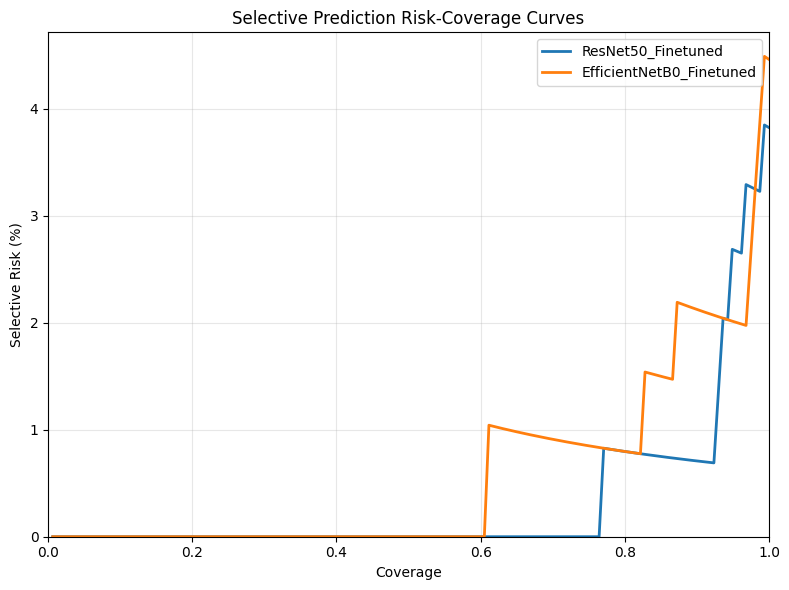

✅ Saved: /kaggle/working/phaseG_risk_coverage_curve.png


In [10]:
# ============================================================
# CELL 10 — FIGURE 1: RISK-COVERAGE CURVES
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in MODEL_NAMES:
    result = risk_coverage_results[
        model_name
    ]

    plt.plot(
        result["coverage_confidence"],
        result["risk_confidence"] * 100,
        linewidth=2,
        label=model_name
    )

plt.xlabel("Coverage")
plt.ylabel("Selective Risk (%)")
plt.title("Selective Prediction Risk-Coverage Curves")
plt.xlim(0, 1)
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

RISK_COVERAGE_PLOT = (
    "/kaggle/working/"
    "phaseG_risk_coverage_curve.png"
)

plt.savefig(
    RISK_COVERAGE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", RISK_COVERAGE_PLOT)


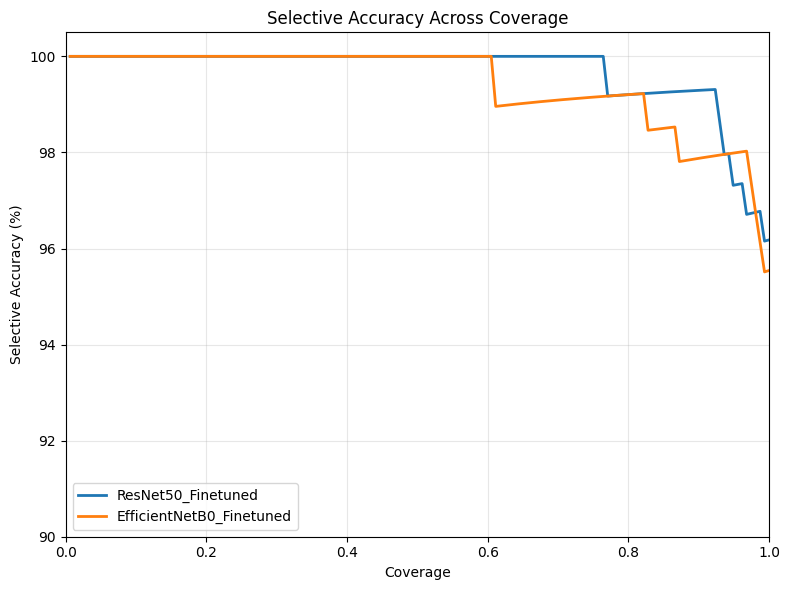

✅ Saved: /kaggle/working/phaseG_selective_accuracy_vs_coverage.png


In [11]:
# ============================================================
# CELL 11 — FIGURE 2: SELECTIVE ACCURACY VS COVERAGE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in MODEL_NAMES:
    result = risk_coverage_results[
        model_name
    ]

    plt.plot(
        result["coverage_confidence"],
        result[
            "selective_accuracy_confidence"
        ] * 100,
        linewidth=2,
        label=model_name
    )

plt.xlabel("Coverage")
plt.ylabel("Selective Accuracy (%)")
plt.title("Selective Accuracy Across Coverage")
plt.xlim(0, 1)
plt.ylim(90, 100.5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

SELECTIVE_ACC_PLOT = (
    "/kaggle/working/"
    "phaseG_selective_accuracy_vs_coverage.png"
)

plt.savefig(
    SELECTIVE_ACC_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", SELECTIVE_ACC_PLOT)


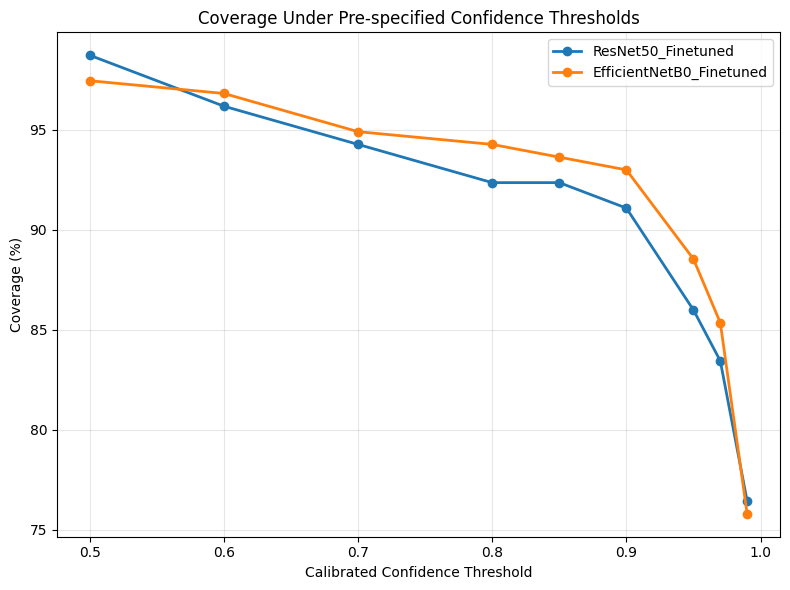

✅ Saved: /kaggle/working/phaseG_threshold_vs_coverage.png


In [12]:
# ============================================================
# CELL 12 — FIGURE 3: THRESHOLD VS COVERAGE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in MODEL_NAMES:
    temp = threshold_df[
        threshold_df["Model"]
        == model_name
    ]

    plt.plot(
        temp["Confidence Threshold"],
        temp["Coverage"] * 100,
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Calibrated Confidence Threshold")
plt.ylabel("Coverage (%)")
plt.title("Coverage Under Pre-specified Confidence Thresholds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

THRESHOLD_COVERAGE_PLOT = (
    "/kaggle/working/"
    "phaseG_threshold_vs_coverage.png"
)

plt.savefig(
    THRESHOLD_COVERAGE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", THRESHOLD_COVERAGE_PLOT)


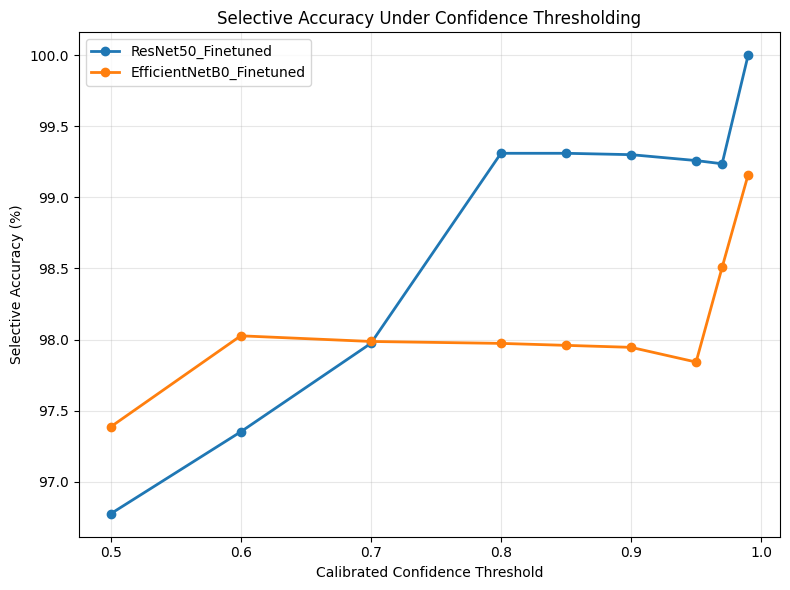

✅ Saved: /kaggle/working/phaseG_threshold_vs_selective_accuracy.png


In [13]:
# ============================================================
# CELL 13 — FIGURE 4: THRESHOLD VS SELECTIVE ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in MODEL_NAMES:
    temp = threshold_df[
        threshold_df["Model"]
        == model_name
    ]

    plt.plot(
        temp["Confidence Threshold"],
        temp["Selective Accuracy"] * 100,
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Calibrated Confidence Threshold")
plt.ylabel("Selective Accuracy (%)")
plt.title("Selective Accuracy Under Confidence Thresholding")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

THRESHOLD_ACC_PLOT = (
    "/kaggle/working/"
    "phaseG_threshold_vs_selective_accuracy.png"
)

plt.savefig(
    THRESHOLD_ACC_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", THRESHOLD_ACC_PLOT)


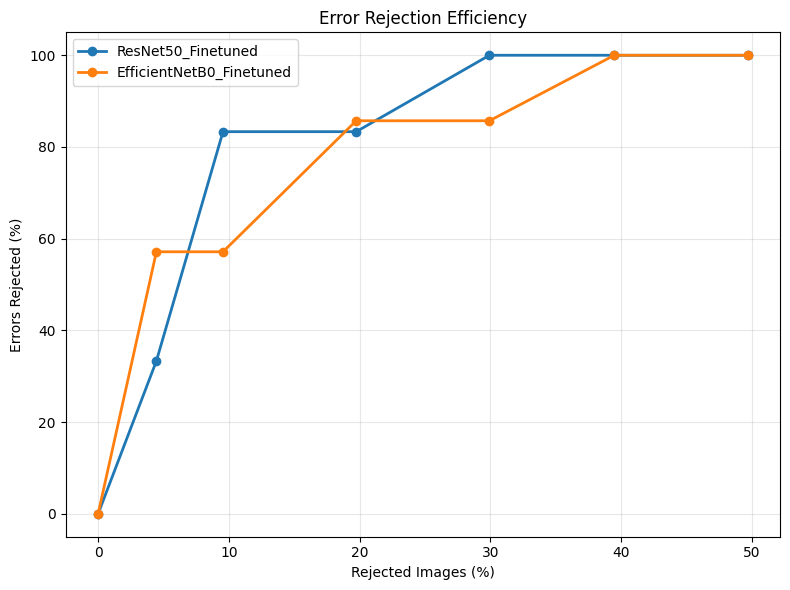

✅ Saved: /kaggle/working/phaseG_error_rejection_efficiency.png


In [14]:
# ============================================================
# CELL 14 — FIGURE 5: ERROR REJECTION EFFICIENCY
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in MODEL_NAMES:
    temp = fixed_coverage_df[
        fixed_coverage_df["Model"]
        == model_name
    ].copy()

    rejection_rate = (
        1.0 - temp["Actual Coverage"]
    )

    plt.plot(
        rejection_rate * 100,
        temp["Error Rejection Rate"] * 100,
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Rejected Images (%)")
plt.ylabel("Errors Rejected (%)")
plt.title("Error Rejection Efficiency")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ERROR_REJECTION_PLOT = (
    "/kaggle/working/"
    "phaseG_error_rejection_efficiency.png"
)

plt.savefig(
    ERROR_REJECTION_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", ERROR_REJECTION_PLOT)


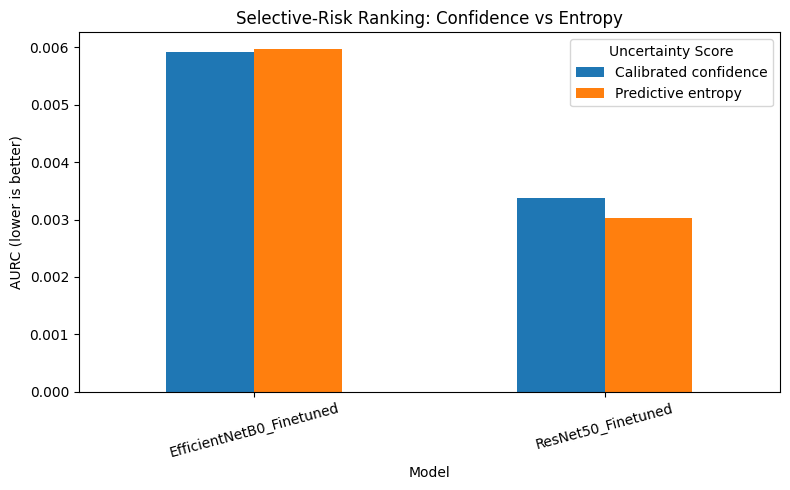

✅ Saved: /kaggle/working/phaseG_aurc_score_comparison.png


In [15]:
# ============================================================
# CELL 15 — FIGURE 6: CONFIDENCE VS ENTROPY AURC
# ============================================================

aurc_pivot = aurc_df.pivot(
    index="Model",
    columns="Uncertainty Score",
    values="AURC"
)

aurc_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("AURC (lower is better)")
plt.xlabel("Model")
plt.title("Selective-Risk Ranking: Confidence vs Entropy")
plt.xticks(rotation=15)
plt.tight_layout()

AURC_COMPARE_PLOT = (
    "/kaggle/working/"
    "phaseG_aurc_score_comparison.png"
)

plt.savefig(
    AURC_COMPARE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", AURC_COMPARE_PLOT)


In [16]:
# ============================================================
# CELL 16 — SAVE FULL RISK-COVERAGE CURVE POINTS
# ============================================================

curve_rows = []

for model_name in MODEL_NAMES:
    result = risk_coverage_results[
        model_name
    ]

    n_points = len(
        result["coverage_confidence"]
    )

    for i in range(n_points):
        curve_rows.append({
            "Model": model_name,
            "Rank": i + 1,
            "Coverage":
                result["coverage_confidence"][i],
            "Risk - Confidence":
                result["risk_confidence"][i],
            "Selective Accuracy - Confidence":
                result["selective_accuracy_confidence"][i],
            "Risk - Entropy":
                result["risk_entropy"][i],
            "Selective Accuracy - Entropy":
                result["selective_accuracy_entropy"][i],
        })

curve_points_df = pd.DataFrame(
    curve_rows
)

CURVE_POINTS_PATH = (
    "/kaggle/working/"
    "phaseG_risk_coverage_curve_points.csv"
)

curve_points_df.to_csv(
    CURVE_POINTS_PATH,
    index=False
)

print("✅ Saved:", CURVE_POINTS_PATH)


✅ Saved: /kaggle/working/phaseG_risk_coverage_curve_points.csv


In [17]:
# ============================================================
# CELL 17 — PHASE G METADATA
# ============================================================

phaseG_metadata = {
    "phase":
        "Phase G — Selective Prediction / Risk-Coverage",

    "source":
        "Phase F calibrated locked-Test probabilities",

    "test_images":
        EXPECTED_TEST_IMAGES,

    "num_classes":
        EXPECTED_CLASSES,

    "models":
        MODEL_NAMES,

    "primary_uncertainty_score":
        "Calibrated maximum softmax probability",

    "secondary_uncertainty_score":
        "Predictive entropy",

    "metrics": [
        "Coverage",
        "Selective Accuracy",
        "Selective Risk",
        "AURC",
        "E-AURC",
        "Error Rejection Rate",
    ],

    "confidence_thresholds":
        CONFIDENCE_THRESHOLDS,

    "fixed_coverage_levels":
        TARGET_COVERAGES,

    "thresholds_optimized_on_test":
        False,

    "model_training_performed":
        False,

    "model_inference_performed":
        False,

    "note":
        (
            "Threshold sweeps are descriptive locked-Test evaluation only. "
            "A deployment threshold should be selected on Validation or "
            "an external development set, not on the locked Test set."
        ),
}

METADATA_PATH = (
    "/kaggle/working/"
    "phaseG_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as f:
    json.dump(
        phaseG_metadata,
        f,
        indent=2
    )

print(
    json.dumps(
        phaseG_metadata,
        indent=2
    )
)

print("\n✅ Saved:", METADATA_PATH)


{
  "phase": "Phase G \u2014 Selective Prediction / Risk-Coverage",
  "source": "Phase F calibrated locked-Test probabilities",
  "test_images": 157,
  "num_classes": 14,
  "models": [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned"
  ],
  "primary_uncertainty_score": "Calibrated maximum softmax probability",
  "secondary_uncertainty_score": "Predictive entropy",
  "metrics": [
    "Coverage",
    "Selective Accuracy",
    "Selective Risk",
    "AURC",
    "E-AURC",
    "Error Rejection Rate"
  ],
  "confidence_thresholds": [
    0.5,
    0.6,
    0.7,
    0.8,
    0.85,
    0.9,
    0.95,
    0.97,
    0.99
  ],
  "fixed_coverage_levels": [
    1.0,
    0.95,
    0.9,
    0.8,
    0.7,
    0.6,
    0.5
  ],
  "thresholds_optimized_on_test": false,
  "model_training_performed": false,
  "model_inference_performed": false,
  "note": "Threshold sweeps are descriptive locked-Test evaluation only. A deployment threshold should be selected on Validation or an external development s

In [18]:
# ============================================================
# CELL 18 — FINAL PHASE-G ARTIFACT ZIP
# ============================================================

PHASE_G_ZIP = (
    "/kaggle/working/"
    "AquaPlant_PhaseG_Selective_Prediction_Artifacts.zip"
)

files_to_backup = []

for filename in os.listdir(
    "/kaggle/working"
):
    full_path = os.path.join(
        "/kaggle/working",
        filename
    )

    if not os.path.isfile(
        full_path
    ):
        continue

    if filename.startswith(
        "phaseG_"
    ) and filename.lower().endswith(
        (
            ".csv",
            ".png",
            ".json",
            ".npz",
        )
    ):
        files_to_backup.append(
            full_path
        )

with zipfile.ZipFile(
    PHASE_G_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for file_path in files_to_backup:
        zipf.write(
            file_path,
            arcname=os.path.basename(
                file_path
            )
        )

with zipfile.ZipFile(
    PHASE_G_ZIP,
    "r"
) as zipf:
    bad_file = zipf.testzip()
    contents = zipf.namelist()

assert bad_file is None

print("=" * 78)
print("PHASE G FINAL BACKUP")
print("=" * 78)

print("\nZIP:")
print(PHASE_G_ZIP)

print(
    "\nFiles included:",
    len(contents)
)

for item in sorted(contents):
    print(" -", item)

print(
    "\nZIP size:",
    f"{os.path.getsize(PHASE_G_ZIP) / (1024 ** 2):.2f} MB"
)

print("\n✅ ZIP integrity check PASSED")
print("✅ PHASE G SELECTIVE PREDICTION COMPLETE")
print(
    "✅ Download "
    "AquaPlant_PhaseG_Selective_Prediction_Artifacts.zip"
)


PHASE G FINAL BACKUP

ZIP:
/kaggle/working/AquaPlant_PhaseG_Selective_Prediction_Artifacts.zip

Files included: 16
 - phaseG_EfficientNetB0_Finetuned_per_image_scores.csv
 - phaseG_ResNet50_Finetuned_per_image_scores.csv
 - phaseG_aurc_score_comparison.png
 - phaseG_aurc_summary.csv
 - phaseG_confidence_threshold_sweep.csv
 - phaseG_error_rejection_efficiency.png
 - phaseG_fixed_coverage_results.csv
 - phaseG_high_confidence_errors.csv
 - phaseG_low_confidence_correct_cases.csv
 - phaseG_metadata.json
 - phaseG_risk_coverage_curve.png
 - phaseG_risk_coverage_curve_points.csv
 - phaseG_selective_accuracy_vs_coverage.png
 - phaseG_selective_prediction_summary.csv
 - phaseG_threshold_vs_coverage.png
 - phaseG_threshold_vs_selective_accuracy.png

ZIP size: 0.77 MB

✅ ZIP integrity check PASSED
✅ PHASE G SELECTIVE PREDICTION COMPLETE
✅ Download AquaPlant_PhaseG_Selective_Prediction_Artifacts.zip


## Interpretation guide

For the paper:

- **Lower AURC / E-AURC is better.**
- As coverage decreases, selective risk should generally decrease and selective accuracy should increase.
- Error Rejection Rate shows how many original errors are removed when low-confidence cases are rejected.
- Confidence-threshold results are descriptive locked-Test results only.
- A real deployment threshold should be selected on Validation or a separate development set, not on the locked Test set.